In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

df = pd.read_csv(
    "../data/processed/creditcard_feature_engineered.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Libraries imported successfully!
Dataset loaded successfully!
Shape: (283726, 34)


In [2]:
df_model = df.drop(columns=["Time_Period"])

# Separate features and target
X = df_model.drop(columns=["Class"])
y = df_model["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nClass Distribution:")
print(y.value_counts())

print("\nClass Percentage:")
print((y.value_counts(normalize=True) * 100).round(3))

Features: (283726, 32)
Target: (283726,)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class Percentage:
Class
0    99.833
1     0.167
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (226980, 32)
Testing data : (56746, 32)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [4]:
rf_models = {

    "RF Baseline": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "RF Tuned 1": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "RF Tuned 2": RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

trained_rf_models = {}

for name, rf in rf_models.items():

    print(f"\nTraining {name}...")

    rf.fit(X_train, y_train)

    trained_rf_models[name] = rf

    print(f"{name} trained successfully!")


Training RF Baseline...
RF Baseline trained successfully!

Training RF Tuned 1...
RF Tuned 1 trained successfully!

Training RF Tuned 2...
RF Tuned 2 trained successfully!


In [5]:
results = []

for name, rf in trained_rf_models.items():

    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_proba
        )
    })

tuning_results = pd.DataFrame(results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

tuning_results[metric_columns] = (
    tuning_results[metric_columns].round(4)
)

print("Random Forest Model Comparison")
print("=" * 60)

display(tuning_results)

Random Forest Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,RF Baseline,0.9993,0.8372,0.7579,0.7956,0.9672
1,RF Tuned 1,0.9995,0.9333,0.7368,0.8235,0.9722
2,RF Tuned 2,0.9995,0.9333,0.7368,0.8235,0.9764


In [6]:
for name, rf in trained_rf_models.items():

    y_pred = rf.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)

    cm = confusion_matrix(y_test, y_pred)

    print(cm)

    tn, fp, fn, tp = cm.ravel()

    print(f"True Negatives  : {tn}")
    print(f"False Positives : {fp}")
    print(f"False Negatives : {fn}")
    print(f"True Positives  : {tp}")


RF Baseline
----------------------------------------
[[56637    14]
 [   23    72]]
True Negatives  : 56637
False Positives : 14
False Negatives : 23
True Positives  : 72

RF Tuned 1
----------------------------------------
[[56646     5]
 [   25    70]]
True Negatives  : 56646
False Positives : 5
False Negatives : 25
True Positives  : 70

RF Tuned 2
----------------------------------------
[[56646     5]
 [   25    70]]
True Negatives  : 56646
False Positives : 5
False Negatives : 25
True Positives  : 70


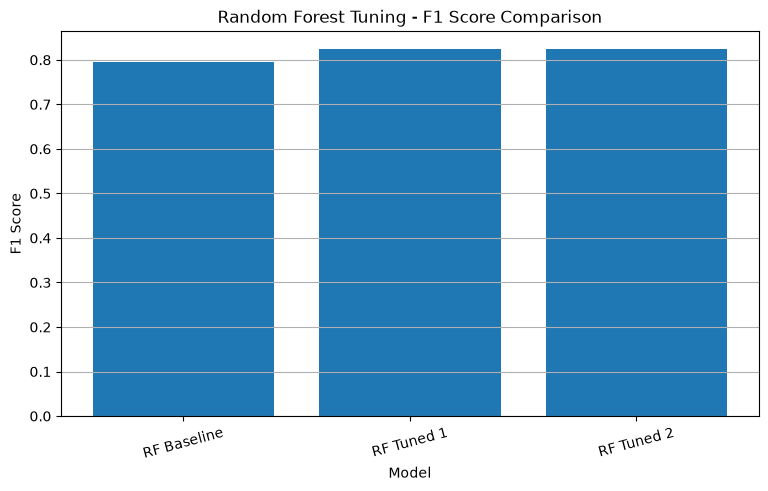

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    tuning_results["Model"],
    tuning_results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Random Forest Tuning - F1 Score Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

In [8]:
best_model_name = tuning_results.loc[
    tuning_results["F1 Score"].idxmax(), "Model"
]

best_model = trained_rf_models[best_model_name]

print("Model selected for threshold analysis:")
print(best_model_name)


# Get fraud probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]


# Thresholds to test
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(threshold_results)

threshold_df[
    ["Precision", "Recall", "F1 Score"]
] = threshold_df[
    ["Precision", "Recall", "F1 Score"]
].round(4)

print("\nThreshold Performance:")
display(threshold_df)

Model selected for threshold analysis:
RF Tuned 1

Threshold Performance:


,Threshold,Precision,Recall,F1 Score
0,0.1,0.3524,0.8421,0.4969
1,0.2,0.6581,0.8105,0.7264
2,0.3,0.7677,0.8000,0.7835
3,0.4,0.8902,0.7684,0.8249
4,0.5,0.9333,0.7368,0.8235
5,0.6,0.9333,0.7368,0.8235
6,0.7,0.9444,0.7158,0.8144
7,0.8,0.9848,0.6842,0.8075
8,0.9,0.9825,0.5895,0.7368


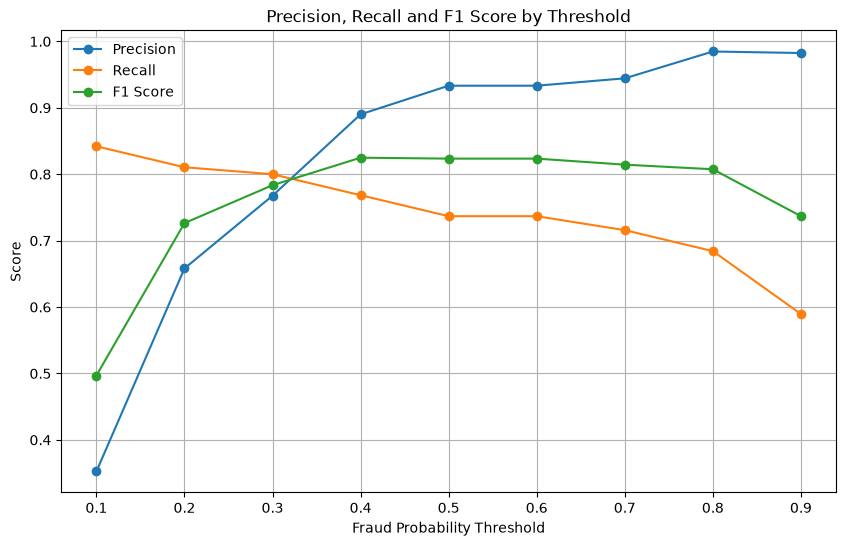

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score by Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold Based on F1 Score")
print("=" * 40)

print(
    f"Threshold : {best_threshold_row['Threshold']:.2f}"
)

print(
    f"Precision : {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score  : {best_threshold_row['F1 Score']:.4f}"
)

Best Threshold Based on F1 Score
Threshold : 0.40
Precision : 0.8902
Recall    : 0.7684
F1 Score  : 0.8249


In [11]:
final_threshold = 0.40

y_pred_tuned = (
    y_proba >= final_threshold
).astype(int)

print("FINAL TUNED MODEL EVALUATION")
print("=" * 50)

print(f"Model     : {best_model_name}")
print(f"Threshold : {final_threshold}")

print("\nMetrics:")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Genuine", "Fraud"]
    )
)

FINAL TUNED MODEL EVALUATION
Model     : RF Tuned 1
Threshold : 0.4

Metrics:
Precision : 0.8902
Recall    : 0.7684
F1 Score  : 0.8249
ROC-AUC   : 0.9722

Confusion Matrix:
[[56642     9]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [12]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/random_forest_tuned.pkl"
)

joblib.dump(
    final_threshold,
    "../models/fraud_threshold.pkl"
)

print("Tuned model saved successfully!")
print("- models/random_forest_tuned.pkl")
print("- models/fraud_threshold.pkl")

Tuned model saved successfully!
- models/random_forest_tuned.pkl
- models/fraud_threshold.pkl
